## 1. Imports et paramètres

In [195]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

# Police plus grande partout
plt.rcParams["font.size"] = 16
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 13


## 2. Répartition des données

In [196]:
FEATURES_PATH = Path("features.csv")
META_PATH = Path("CHAPITRES_METADATA.csv")

features_df = pd.read_csv(FEATURES_PATH, index_col=0)
features_df.index.name = "book_id"
print("Features shape:", features_df.shape)

meta_df = pd.read_csv(META_PATH)
meta_labels = meta_df[["doc_name", "gender"]].copy()
meta_labels = meta_labels[meta_labels["gender"].isin(["male", "female"])]
meta_labels = meta_labels.set_index("doc_name")

# Intersection sur les identifiants de livres
common_books = features_df.index.intersection(meta_labels.index)
print("Nombre de livres communs (features + metadata) :", len(common_books))

df = features_df.loc[common_books].copy()
df["author_gender"] = meta_labels.loc[common_books, "gender"]

print("Répartition du genre de l'auteur :")
print(df["author_gender"].value_counts())

Features shape: (2980, 482)
Nombre de livres communs (features + metadata) : 2917
Répartition du genre de l'auteur :
author_gender
male      2291
female     626
Name: count, dtype: int64


genre_auteur_fr
Femme     626
Homme    2291
Name: count, dtype: int64


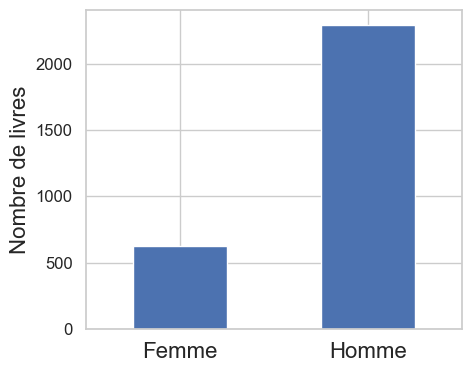

In [212]:

# Compter le nombre de livres par genre d'auteur
counts = df_plot["genre_auteur_fr"].value_counts().sort_index()

print(counts)

# Plot
plt.figure(figsize=(5, 4))
counts.plot(kind="bar")

plt.xticks(rotation=0)
plt.xlabel("")
plt.ylabel("Nombre de livres")

plt.tight_layout()
plt.show()


## 3. Figures descriptives

### 3.1 : Part des mentions féminines selon le genre de l'auteur

C:\Users\arnod\AppData\Local\Temp\ipykernel_31316\2626582048.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


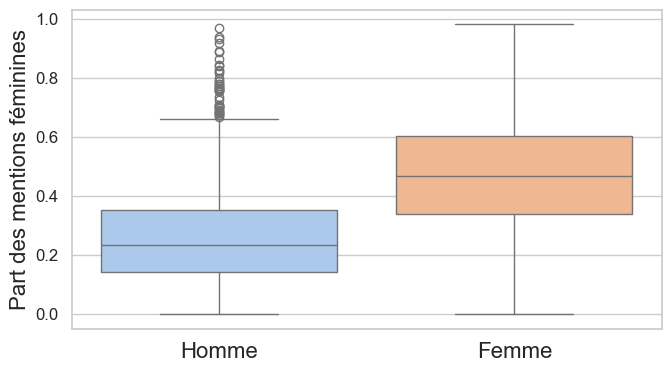

In [197]:

# Remapper male / female -> homme / femme
df_plot = df.copy()
df_plot["genre_auteur_fr"] = df_plot["author_gender"].map(
    {"male": "Homme", "female": "Femme"}
)

plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df_plot,
    x="genre_auteur_fr",
    y="female_mentions_share",
    palette="pastel",
)


plt.xlabel("")
plt.ylabel("Part des mentions féminines")
plt.tight_layout()
plt.show()


### 3.2 : Personnage principal féminin selon le genre de l'auteur

C:\Users\arnod\AppData\Local\Temp\ipykernel_31316\957015660.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


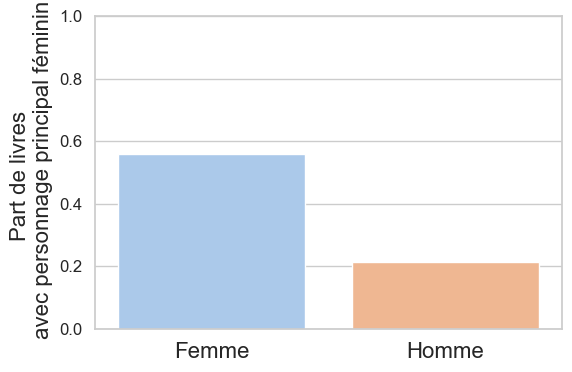

  genre_auteur_fr  top1_char_is_female
0           Femme             0.559105
1           Homme             0.212134


In [198]:
prop_top1_female = (
    df_plot.groupby("genre_auteur_fr")["top1_char_is_female"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(6, 4))
sns.barplot(
    data=prop_top1_female,
    x="genre_auteur_fr",
    y="top1_char_is_female",
    palette="pastel",
)

plt.xlabel("")
plt.ylabel("Part de livres \n avec personnage principal féminin")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print(prop_top1_female)

### 3.3 Ambiguïté du genre des personnages selon le genre de l'auteur

C:\Users\arnod\AppData\Local\Temp\ipykernel_31316\4074148649.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


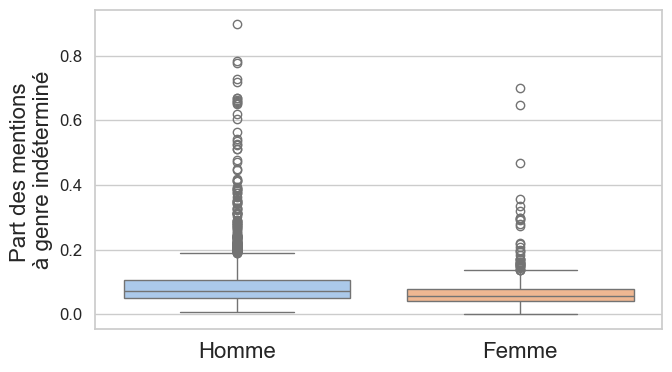

In [199]:

plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df_plot,
    x="genre_auteur_fr",
    y="null_mentions_share",
    palette="pastel",
)


plt.xlabel("")
plt.ylabel("Part des mentions \nà genre indéterminé")
plt.tight_layout()
plt.show()

### 3.4 Adjectifs : part féminine globale vs « jeune »

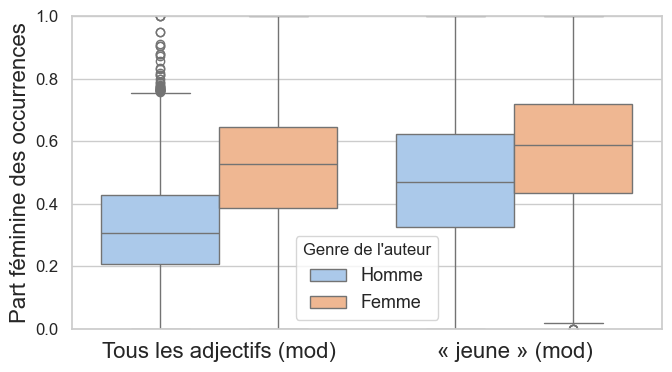

In [200]:
# --- Préparation des données pour les adjectifs ---
cols_mod = ["share_female_mod_tokens", "share_female_mod_jeune"]

mod_df = (
    df_plot[["genre_auteur_fr"] + cols_mod]
    .melt(
        id_vars="genre_auteur_fr",
        value_vars=cols_mod,
        var_name="feature",
        value_name="share_female",
    )
    .dropna(subset=["share_female"])
)

# Labels lisibles pour les deux features
feature_label_map_mod = {
    "share_female_mod_tokens": "Tous les adjectifs (mod)",
    "share_female_mod_jeune": "« jeune » (mod)",
}
mod_df["feature_label"] = mod_df["feature"].map(feature_label_map_mod)


plt.figure(figsize=(7, 4))
sns.boxplot(
    data=mod_df,
    x="feature_label",
    y="share_female",
    hue="genre_auteur_fr",
    palette="pastel",
)

plt.xlabel("")
plt.ylabel("Part féminine des occurrences")
plt.ylim(0, 1)
plt.legend(title="Genre de l'auteur")
plt.tight_layout()
plt.show()


### 3.5  : Verbes agents : part associée à des personnages féminins

C:\Users\arnod\AppData\Local\Temp\ipykernel_31316\3930594239.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


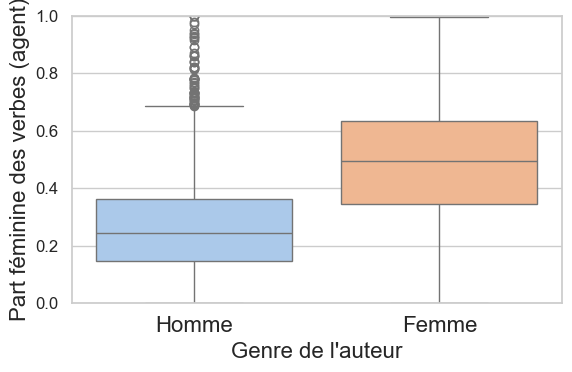

In [201]:


plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df_plot,
    x="genre_auteur_fr",
    y="share_female_agent_tokens",
    palette="pastel",
)

plt.xlabel("Genre de l'auteur")
plt.ylabel("Part féminine des verbes (agent)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


# Annexe : construction de double plots pour le rapport

C:\Users\arnod\AppData\Local\Temp\ipykernel_31316\1669933272.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\arnod\AppData\Local\Temp\ipykernel_31316\1669933272.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


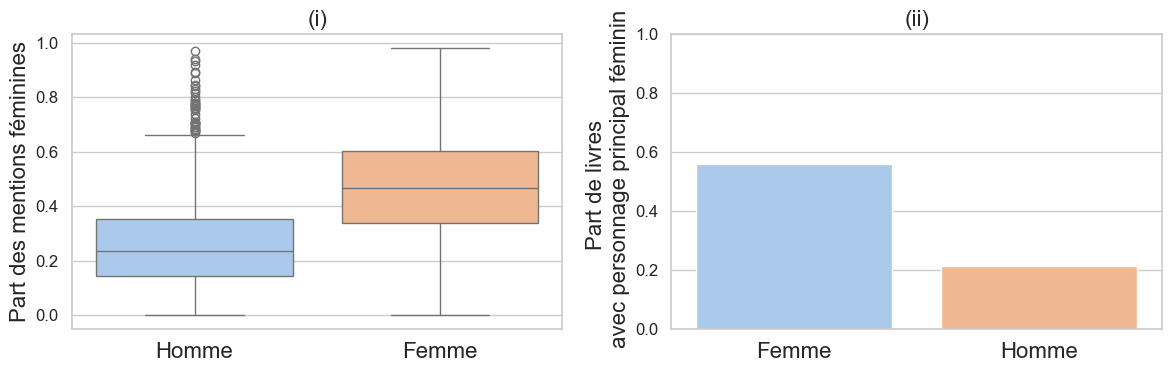

  genre_auteur_fr  top1_char_is_female
0           Femme             0.559105
1           Homme             0.212134


In [204]:
# Remapper male / female -> homme / femme
df_plot = df.copy()
df_plot["genre_auteur_fr"] = df_plot["author_gender"].map(
    {"male": "Homme", "female": "Femme"}
)

# Proportion de top1 féminin par genre d'auteur
prop_top1_female = (
    df_plot.groupby("genre_auteur_fr")["top1_char_is_female"]
           .mean()
           .reset_index()
)

# --- Figure commune : plot 1 (i) + plot 2 (ii) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1 : boxplot part des mentions féminines
sns.boxplot(
    data=df_plot,
    x="genre_auteur_fr",
    y="female_mentions_share",
    palette="pastel",
    ax=axes[0],
)
axes[0].set_title("(i)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Part des mentions féminines")

# Plot 2 : barplot part de livres avec perso principal féminin
sns.barplot(
    data=prop_top1_female,
    x="genre_auteur_fr",
    y="top1_char_is_female",
    palette="pastel",
    ax=axes[1],
)
axes[1].set_title("(ii)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Part de livres \n avec personnage principal féminin")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(prop_top1_female)


C:\Users\arnod\AppData\Local\Temp\ipykernel_31316\1466380133.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


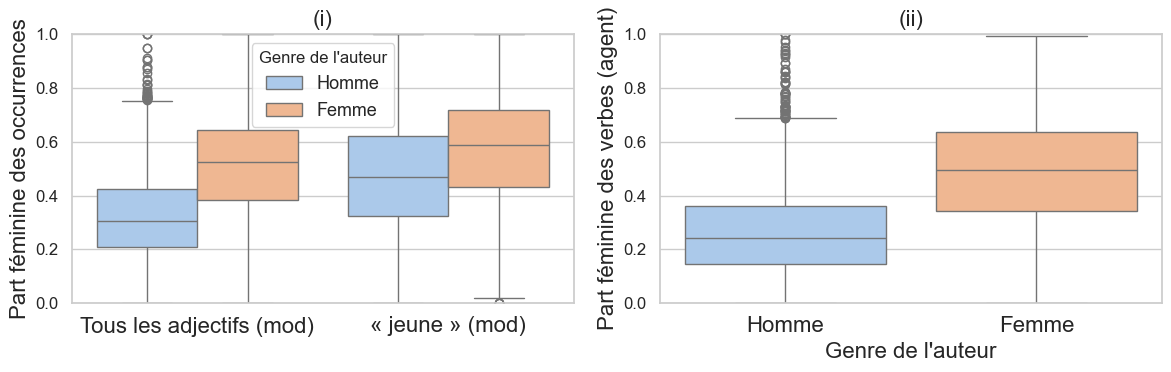

In [206]:
# --- Préparation des données pour les adjectifs ---
cols_mod = ["share_female_mod_tokens", "share_female_mod_jeune"]

mod_df = (
    df_plot[["genre_auteur_fr"] + cols_mod]
    .melt(
        id_vars="genre_auteur_fr",
        value_vars=cols_mod,
        var_name="feature",
        value_name="share_female",
    )
    .dropna(subset=["share_female"])
)

# Labels lisibles pour les deux features
feature_label_map_mod = {
    "share_female_mod_tokens": "Tous les adjectifs (mod)",
    "share_female_mod_jeune": "« jeune » (mod)",
}
mod_df["feature_label"] = mod_df["feature"].map(feature_label_map_mod)

# --- Figure commune : plot 4 (iv) + plot 5 (v) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 4 : adjectifs, par type de feature
sns.boxplot(
    data=mod_df,
    x="feature_label",
    y="share_female",
    hue="genre_auteur_fr",
    palette="pastel",
    ax=axes[0],
)
axes[0].set_title("(i)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Part féminine des occurrences")
axes[0].set_ylim(0, 1)
axes[0].legend(title="Genre de l'auteur")

# Plot 5 : part féminine des verbes (agent)
sns.boxplot(
    data=df_plot,
    x="genre_auteur_fr",
    y="share_female_agent_tokens",
    palette="pastel",
    ax=axes[1],
)
axes[1].set_title("(ii)")
axes[1].set_xlabel("Genre de l'auteur")
axes[1].set_ylabel("Part féminine des verbes (agent)")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()
